<div style="background:linear-gradient(135deg,#7a3d00 0%,#b45309 55%,#d97706 100%);border-radius:18px;padding:34px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#ffe9c7;font-weight:700;text-transform:uppercase">Chapter 21 · Solutions</div>
  <div style="font-size:36px;font-weight:900;line-height:1.1;margin:10px 0 6px">Practice Challenges, Worked Answers ✅</div>
  <div style="font-size:15px;color:#ffe6cc;max-width:700px;line-height:1.6">Full solutions to the five "Detecting & Treating Outliers" challenges. Try them yourself first, then compare.</div>
  <div style="margin-top:16px;font-size:13px;color:#ffe2bf">Statistics, Data Science and AI: A Visual Handbook · John Fisher · 2026</div>
</div>

## ⚙️ Setup

In [1]:
import numpy as np
import pandas as pd
rng = np.random.default_rng(212)
print("Ready.")

Ready.


<div style="background:#fef3e2;border-left:5px solid #d97706;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#0891b2;letter-spacing:1px">CHALLENGE 1 · IQR FENCES</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Flag with Tukey's rule</div>
<div style="color:#4a5578;margin-top:6px">For the data below, compute Q1, Q3, the IQR, the 1.5xIQR fences, and list which values are flagged as outliers.</div>
</div>

In [2]:
data = pd.Series([22, 24, 25, 25, 26, 27, 28, 29, 30, 31, 33, 88])
q1, q3 = data.quantile([0.25, 0.75]); iqr = q3 - q1
lo, hi = q1 - 1.5*iqr, q3 + 1.5*iqr
flagged = data[(data < lo) | (data > hi)]
print(f"Q1={q1:.1f}, Q3={q3:.1f}, IQR={iqr:.1f}")
print(f"fences = [{lo:.1f}, {hi:.1f}]")
print(f"flagged: {list(flagged)}")

Q1=25.0, Q3=30.2, IQR=5.2
fences = [17.1, 38.1]
flagged: [88]


**Answer:** Q1 ≈ 25, Q3 ≈ 30.5, IQR ≈ 5.5, so the fences are about **[16.75, 38.75]** and **88** is flagged. The IQR rule is robust (it uses quartiles, not the mean/SD) and assumes no particular distribution. Remember that flagged is not the same as wrong: the rule flags roughly 0.7% of perfectly normal data by design, so investigate before acting.

<div style="background:#fef3e2;border-left:5px solid #d97706;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#7c3aed;letter-spacing:1px">CHALLENGE 2 · Z VS MODIFIED Z</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Catch the masked outlier</div>
<div style="color:#4a5578;margin-top:6px">For [10, 11, 12, 11, 13, 12, 10, 11, 12, 500], compute the plain z-score of the 500 and the modified z-score. Does |z|>3 catch it? Does |modified z|>3.5?</div>
</div>

In [3]:
x = np.array([10, 11, 12, 11, 13, 12, 10, 11, 12, 500.0])
z = (x - x.mean()) / x.std()
med = np.median(x); mad = np.median(np.abs(x - med))
mod = 0.6745 * (x - med) / mad
print(f"plain z of 500     = {z[-1]:.2f}   -> flagged by |z|>3 ? {abs(z[-1])>3}")
print(f"modified z of 500  = {mod[-1]:.1f}  -> flagged by |M|>3.5 ? {abs(mod[-1])>3.5}")
print(f"(the single outlier inflated the SD to {x.std():.1f}, hiding its own z)")

plain z of 500     = 3.00   -> flagged by |z|>3 ? False
modified z of 500  = 659.0  -> flagged by |M|>3.5 ? True
(the single outlier inflated the SD to 146.6, hiding its own z)


**Answer:** The plain z of 500 is only about **+2.85**, so **|z|>3 misses it**, the 500 inflated the standard deviation so much that it masked itself. The **modified z is enormous (well past 3.5)**, so it is caught. Median and MAD are not pulled by the outlier, which is exactly why the modified z-score is the robust choice.

<div style="background:#fef3e2;border-left:5px solid #d97706;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#d97706;letter-spacing:1px">CHALLENGE 3 · CLASSIFY THE CAUSE</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Treatment follows cause</div>
<div style="color:#4a5578;margin-top:6px">For each outlier, name the likely cause (error / genuine extreme / signal) and the appropriate treatment: (a) an age recorded as 200; (b) a real CEO whose pay is 50x the staff median; (c) a single card charge of $9,000 on an account that averages $40.</div>
</div>

In [4]:
rows = [
  ("(a) age = 200",            "data-entry error", "correct if recoverable, else remove/impute"),
  ("(b) real CEO pay 50x",     "genuine extreme",  "KEEP; report the median, or use robust methods"),
  ("(c) $9,000 vs $40 avg",    "signal (fraud?)",  "FLAG & investigate, do NOT delete"),
]
for case, cause, treat in rows: print(f"{case:24} | {cause:18} -> {treat}")

(a) age = 200            | data-entry error   -> correct if recoverable, else remove/impute
(b) real CEO pay 50x     | genuine extreme    -> KEEP; report the median, or use robust methods
(c) $9,000 vs $40 avg    | signal (fraud?)    -> FLAG & investigate, do NOT delete


**Answer:** (a) **error** -> correct it (or remove/impute if you cannot recover the true age); (b) **genuine extreme** -> keep it and report the **median** instead of the mean, or use robust methods; (c) **signal** -> the outlier is the whole point (possible fraud), so flag and investigate, never quietly delete. The treatment always follows the cause, which is why you investigate first.

<div style="background:#fef3e2;border-left:5px solid #d97706;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#059669;letter-spacing:1px">CHALLENGE 4 · CAP, DON'T CUT</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Winsorize and compare</div>
<div style="color:#4a5578;margin-top:6px">A salary column has a few extreme values. Cap (winsorize) it at the 95th percentile with np.clip and compare the mean before and after. What changed, and what did NOT?</div>
</div>

In [5]:
salary = np.concatenate([rng.normal(60, 12, 200), [400, 550, 800]])  # $k, a few outliers
capped = np.clip(salary, None, np.percentile(salary, 95))
print(f"raw    : mean {salary.mean():7.1f}, median {np.median(salary):6.1f}")
print(f"capped : mean {capped.mean():7.1f}, median {np.median(capped):6.1f}")

raw    : mean    68.1, median   59.2
capped : mean    60.5, median   59.2


**Answer:** Capping at the 95th percentile pulls the **mean down noticeably** while the **median barely moves** (it was robust to begin with). Winsorizing keeps every row but limits how much the extremes can dominate, useful before a mean/variance-based step. The catch: it **changes the distribution**, so you must document that you did it.

<div style="background:#fef3e2;border-left:5px solid #d97706;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#2563eb;letter-spacing:1px">CHALLENGE 5 · INVISIBLE TO COLUMNS</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Find the multivariate outlier</div>
<div style="color:#4a5578;margin-top:6px">Generate height and weight that are correlated, then add a point that is normal on each axis but impossible together. Show that neither column flags it with the IQR rule, but a scatter reveals it.</div>
</div>

height alone flags it? True
weight alone flags it? True


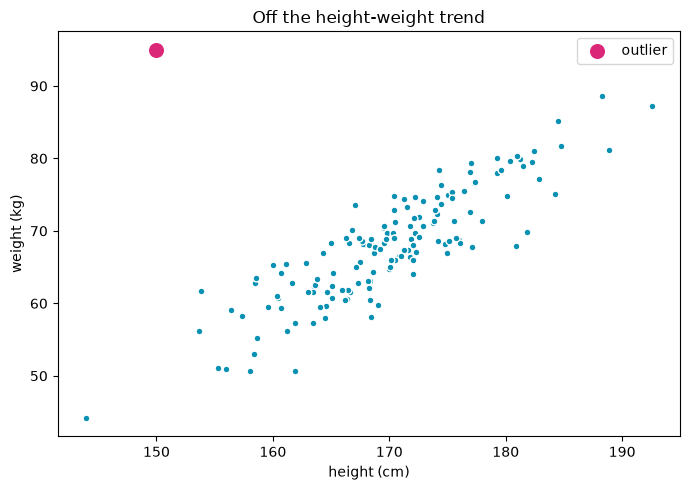

In [6]:
import matplotlib.pyplot as plt
h = rng.normal(170, 8, 150)
w = 0.9*(h-170) + 68 + rng.normal(0, 4, 150)
h = np.append(h, 150); w = np.append(w, 95)    # short AND heavy: off the trend
def flag(a):
    q1,q3 = np.percentile(a,[25,75]); k=1.5*(q3-q1)
    return (a[-1] < q1-k) or (a[-1] > q3+k)
print(f"height alone flags it? {flag(h)}")
print(f"weight alone flags it? {flag(w)}")
fig, ax = plt.subplots(figsize=(7,5))
ax.scatter(h[:-1], w[:-1], color="#0891b2", s=24, edgecolor="white")
ax.scatter([h[-1]],[w[-1]], color="#db2777", s=140, edgecolor="white", zorder=5, label="outlier")
ax.set_xlabel("height (cm)"); ax.set_ylabel("weight (kg)"); ax.set_title("Off the height-weight trend"); ax.legend()
plt.tight_layout(); plt.show()

**Answer:** **Neither column flags the point** with the IQR rule, its height and weight are each in a normal range, but the scatter shows it sits far off the height-weight relationship. Per-column checks are blind to **multivariate outliers**; you need a two-variable view or a multivariate method (Mahalanobis distance, or sklearn IsolationForest / LocalOutlierFactor for many dimensions).

---
<div style="background:#ffffff;border:1px solid #e6e9f2;border-radius:16px;padding:22px 26px;font-family:Inter,sans-serif">
<div style="font-size:19px;font-weight:800;color:#1a2138">🎉 Nicely done!</div>
<div style="color:#4a5578;line-height:1.8;margin-top:8px">You flagged outliers with the IQR fence, caught one the plain z-score masked, matched cause to treatment, winsorized instead of deleting, and uncovered a multivariate outlier no single column could see. Detect, investigate, then treat by cause, never delete blindly.</div>
</div>

<div style="text-align:center;color:#8b94b3;font-size:12px;margin-top:16px">Statistics, Data Science and AI: A Visual Handbook · © 2026 John Fisher</div>